## What's in the notebook?
I cleaned dataset called 'daibetes' by:-
#### -> analyzing
#### -> handling missing values
#### -> handling duplicate values
#### -> analyzing and removing outliers 
#### -> analyzing correlations
#### -> scaling(normalizing) the dataset.

### How to have this dataset?
It is publicly available on Kaggle.com with many variants. I used a messy one.

In [70]:
# Importing important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [71]:
# reading the dataset
df= pd.read_csv('diabetes.csv')

In [72]:
# looking at the data with naked eye to analyze
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
df.shape

(768, 9)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [22]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [73]:
# checking for null values but there aren't any
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [74]:
# checking for duplicate values but there aren't any
df.duplicated().sum()

np.int64(0)

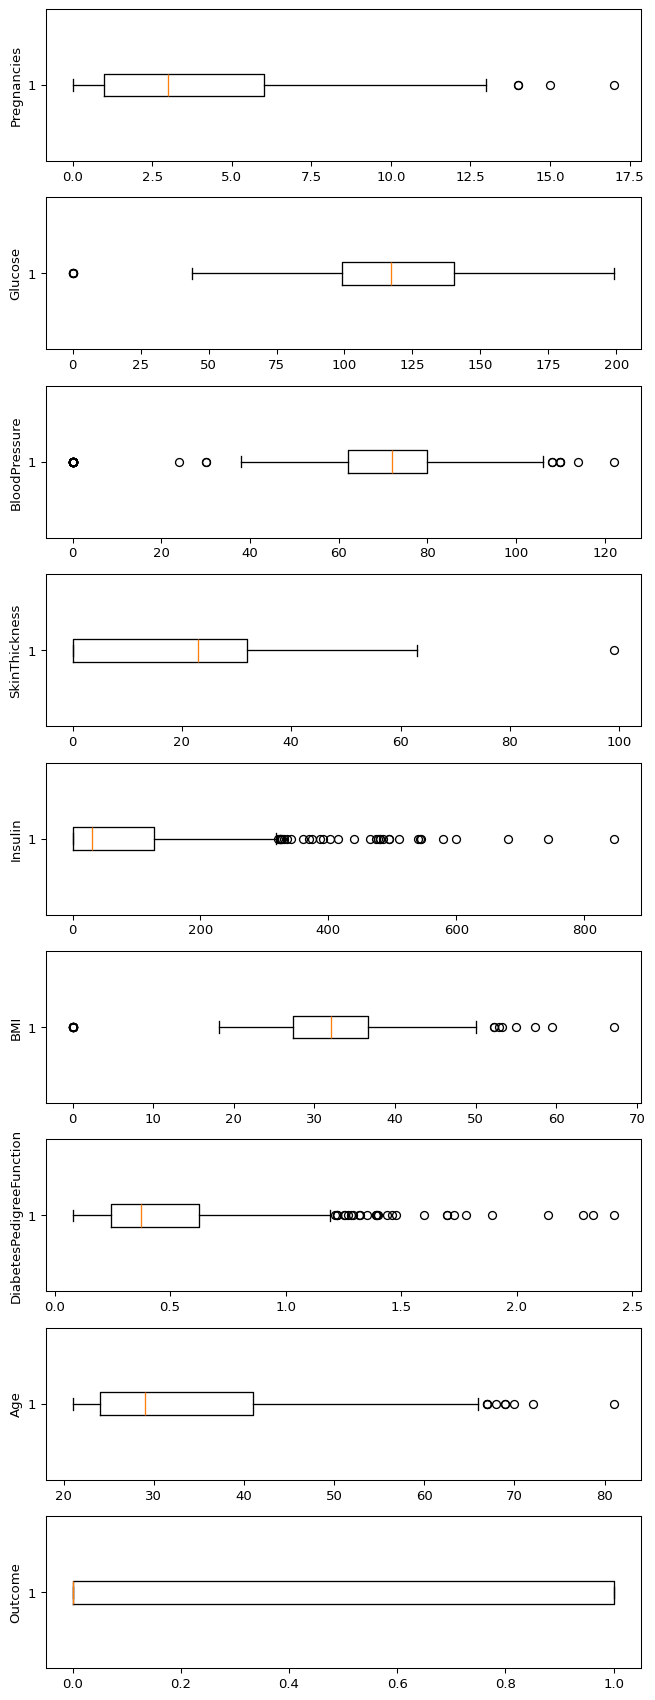

In [75]:
# plotting each input feature's boxplot to analyze the outliers
fig, axs= plt.subplots(len(df.columns), 1, figsize= (7, 18), dpi= 95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert= False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [38]:
clean_df= df.copy()

In [76]:
# handling the outliers very very gracefully (removing them)
for i, col in enumerate(clean_df.columns):
    q1, q3= np.percentile(clean_df[col], [25, 75])
    iqr= q3-q1
    lower= q1- 1.5*iqr
    higher= q3+ 1.5*iqr
    clean_df= clean_df[(clean_df[col]>= lower) & (clean_df[col]<= higher)]
    

In [47]:
clean_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [77]:
# finding correlations and also plotting there heatmap later
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


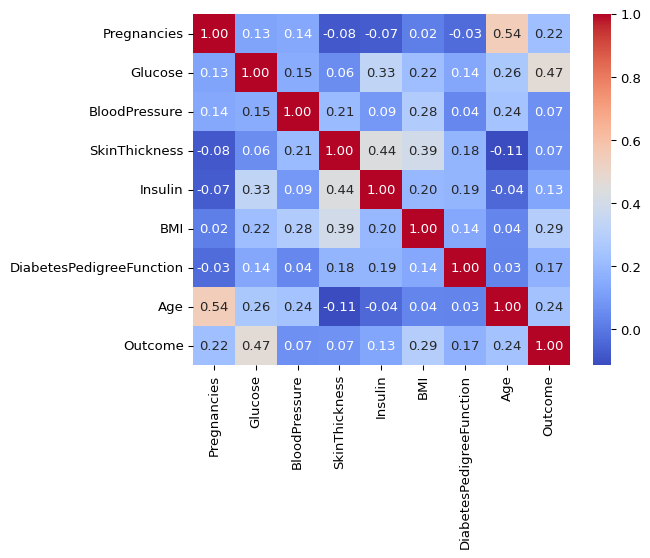

In [78]:
corr= df.corr()

plt.figure(dpi= 95)
sns.heatmap(corr, annot= True, fmt= '.2f', cmap= 'coolwarm')
plt.show()

In [79]:
# looking against output feature
corr['Outcome'].sort_values()

BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
DiabetesPedigreeFunction    0.173844
Pregnancies                 0.221898
Age                         0.238356
BMI                         0.292695
Glucose                     0.466581
Outcome                     1.000000
Name: Outcome, dtype: float64

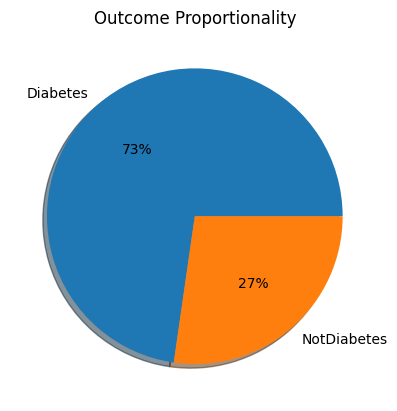

In [80]:
# looking for output distribution
plt.pie(clean_df['Outcome'].value_counts(),
        labels= ['Diabetes', 'NotDiabetes'],
        autopct= '%.f%%',
        shadow= True)
plt.title('Outcome Proportionality')
plt.show()

In [81]:
# separating input features from output feature
X= clean_df.drop(columns= ['Outcome'])
y= clean_df['Outcome']

In [64]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
5,5,116,74,0,0,25.6,0.201,30
...,...,...,...,...,...,...,...,...
762,9,89,62,0,0,22.5,0.142,33
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [65]:
y

0      1
1      0
2      1
3      0
5      0
      ..
762    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 577, dtype: int64

In [82]:
# normalizing (scaling- minmax)
from sklearn.preprocessing import StandardScaler

In [68]:
scaler= StandardScaler()
X_standardized= scaler.fit_transform(X)

In [69]:
X_standardized

array([[ 0.7100893 ,  1.20823791,  0.0445859 , ...,  0.29079958,
         0.94652763,  1.92737158],
       [-0.84306281, -1.16111292, -0.50472504, ..., -0.82250802,
        -0.27033495, -0.04001898],
       [ 1.33135014,  2.52454393, -0.68782868, ..., -1.34735303,
         1.14492914,  0.06352789],
       ...,
       [ 0.39945888,  0.19280184,  0.0445859 , ..., -0.8861256 ,
        -0.73768072, -0.14356585],
       [-0.84306281,  0.38084556, -1.05403598, ..., -0.26585422,
        -0.27915279,  1.61673096],
       [-0.84306281, -0.86024297, -0.13851775, ..., -0.21814103,
        -0.42905616, -0.86839395]], shape=(577, 8))